# Lab 06 · Instructor solution

Compare equivalent formulas and then implement subdivision with complete coverage. Use exact rational intervals so changes in width come from the enclosure method.

In [1]:
from fractions import Fraction
import matplotlib.pyplot as plt
from IPython.display import display
from vc.intervals import RationalInterval as Interval
from vc.arb_bridge import evaluate_ball

def expanded(X):
    return X - X.square()

def product(X):
    return X * (1 - X)

def vertex(X):
    return Fraction(1, 4) - (X - Fraction(1, 2)).square()

domain = Interval(0, 1)
true_range = Interval(0, Fraction(1, 4))

## Task A · Three formulas (25 minutes)

Evaluate the three formulas on [0, 1]. Derive the true range analytically and compare enclosure widths.

In [2]:
for name, formula in [("expanded", expanded), ("product", product), ("vertex", vertex)]:
    bound = formula(domain)
    assert true_range.is_subset_of(bound)
    print(name, bound, "width:", bound.width())

expanded [-1, 1] width: 2
product [0, 1] width: 1
vertex [0, 1/4] width: 1/4


**Worked explanation:** The true range is [0, 1/4], from x(1−x) = 1/4 − (x−1/2)². The expanded, product, and vertex bounds are [−1, 1], [0, 1], and [0, 1/4]. Exact rational endpoints already eliminate rounding error; extra digits do not recover dependencies discarded by the first two expressions.

## Task B · Cover, evaluate, combine (50 minutes)

Write uniform subdivision into $2^{depth}$ pieces by repeated bisection, then hull all local images. Require a nonnegative integer depth. Preserve a point domain as one piece.

In [3]:
def split_uniformly(domain, depth):
    if not isinstance(depth, int) or depth < 0:
        raise ValueError("depth must be a nonnegative integer")
    pieces = [domain]
    for level in range(depth):
        next_pieces = []
        for piece in pieces:
            if piece.width() == 0:
                next_pieces.append(piece)
            else:
                left, right = piece.bisect()
                next_pieces.append(left)
                next_pieces.append(right)
        pieces = next_pieces
    return pieces

def enclose_by_pieces(evaluate, domain, depth):
    pieces = split_uniformly(domain, depth)
    bound = evaluate(pieces[0])
    for piece in pieces[1:]:
        local_bound = evaluate(piece)
        bound = bound.hull(local_bound)
    return bound

0 1 [0, 1]
1 2 [0, 1/2]
2 4 [0, 3/8]
3 8 [0, 5/16]
4 16 [0, 9/32]
5 32 [0, 17/64]
6 64 [0, 33/128]


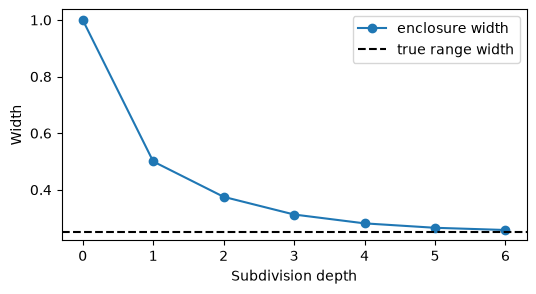

In [4]:
widths = []
for depth in range(7):
    pieces = split_uniformly(domain, depth)
    assert pieces[0].lo == domain.lo
    assert pieces[-1].hi == domain.hi
    for index in range(len(pieces) - 1):
        assert pieces[index].hi == pieces[index + 1].lo
    bound = enclose_by_pieces(product, domain, depth)
    assert true_range.is_subset_of(bound)
    widths.append(float(bound.width()))
    print(depth, len(pieces), bound)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(7), widths, "o-", label="enclosure width")
ax.axhline(0.25, color="black", linestyle="--", label="true range width")
ax.set(xlabel="Subdivision depth", ylabel="Width")
ax.legend()
display(fig)
plt.close(fig)

**Worked explanation:** Every x in the original interval belongs to at least one retained piece, so its image lies in a local enclosure and hence in their hull. The true function varies by 1/4; an enclosing interval cannot be narrower than its true range. Omitting the middle interval loses x=1/2, where the maximum occurs.

## Task C · Certify a transcendental sign (35 minutes)

Use Arb to enclose $(\sin x-x^2+1)\cos x$ on [0, 1/2]. Try a direct evaluation first, then subdivision if necessary. Work at 100 bits. State the certificate using exact endpoints.

In [5]:
def trig_expression(x):
    return (x.sin() - x*x + 1) * x.cos()

def trig_enclosure(X):
    return evaluate_ball(trig_expression, X, precision=100)

In [6]:
trig_domain = Interval(0, Fraction(1, 2))
bound = enclose_by_pieces(trig_enclosure, trig_domain, depth=3)
assert bound.lo > 0
print("Certified enclosure:", bound)
print("Display approximation:", float(bound.lo), float(bound.hi))

Certified enclosure: [315037221090088574082166964087/316912650057057350374175801344, 766315782230205253984513373231/633825300114114700748351602688]
Display approximation: 0.9940821896297573 1.209033123310535


**Worked explanation:** Arb sin, multiplication, addition, and cos enclose their results on the converted input balls. Exact endpoint conversion and complete subdivision preserve inclusion; the exact lower bound is positive. A bound containing zero is inconclusive about zeros, and a finite plot leaves unsampled points unchecked. This expression is Tucker’s Example 3.1.4.